In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("1-employee_salary_dataset (2).csv")

In [4]:
df


,Employee_ID,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
0,EMP10001,28.0,Male,Master,6.0,Operations,Junior,1,4,15,Yes,Chennai,6,5,97.0,35.24
1,EMP10002,26.0,Female,Bachelor,5.0,Operations,Junior,2,3,32,No,Delhi,0,18,62.0,35.87
2,EMP10003,31.0,Female,Bachelor,5.0,Marketing,Junior,4,5,17,Yes,Hyderabad,4,7,98.0,35.40
3,EMP10004,59.0,Female,Bachelor,29.0,Sales,Lead,3,0,46,No,Mumbai,14,18,57.0,73.05
4,EMP10005,23.0,Female,Bachelor,0.0,Sales,Junior,2,4,5,Yes,Hyderabad,0,28,56.0,28.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5015,EMP13816,25.0,Female,PhD,4.0,Operations,Junior,3,6,1,No,Hyderabad,2,16,92.0,46.14
5016,EMP13817,21.0,Male,Bachelor,0.0,Marketing,Junior,1,3,19,Yes,Chennai,0,25,58.0,21.48
5017,EMP13818,60.0,Female,Master,25.0,IT,Lead,4,8,51,No,Hyderabad,10,25,57.0,82.62
5018,EMP13819,32.0,Male,Diploma,10.0,HR,Mid,2,5,12,No,Delhi,7,7,61.0,30.57


In [5]:
df.head()

,Employee_ID,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
0,EMP10001,28.0,Male,Master,6.0,Operations,Junior,1,4,15,Yes,Chennai,6,5,97.0,35.24
1,EMP10002,26.0,Female,Bachelor,5.0,Operations,Junior,2,3,32,No,Delhi,0,18,62.0,35.87
2,EMP10003,31.0,Female,Bachelor,5.0,Marketing,Junior,4,5,17,Yes,Hyderabad,4,7,98.0,35.40
3,EMP10004,59.0,Female,Bachelor,29.0,Sales,Lead,3,0,46,No,Mumbai,14,18,57.0,73.05
4,EMP10005,23.0,Female,Bachelor,0.0,Sales,Junior,2,4,5,Yes,Hyderabad,0,28,56.0,28.83


In [6]:
df.tail()


,Employee_ID,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
5015,EMP13816,25.0,Female,PhD,4.0,Operations,Junior,3,6,1,No,Hyderabad,2,16,92.0,46.14
5016,EMP13817,21.0,Male,Bachelor,0.0,Marketing,Junior,1,3,19,Yes,Chennai,0,25,58.0,21.48
5017,EMP13818,60.0,Female,Master,25.0,IT,Lead,4,8,51,No,Hyderabad,10,25,57.0,82.62
5018,EMP13819,32.0,Male,Diploma,10.0,HR,Mid,2,5,12,No,Delhi,7,7,61.0,30.57
5019,EMP13820,33.0,Male,Bachelor,3.0,Marketing,Junior,1,5,46,Yes,Delhi,3,22,100.0,38.66


In [7]:
df.info

<bound method DataFrame.info of      Employee_ID   Age  Gender Education  Experience_Years  Department  \
0       EMP10001  28.0    Male    Master               6.0  Operations   
1       EMP10002  26.0  Female  Bachelor               5.0  Operations   
2       EMP10003  31.0  Female  Bachelor               5.0   Marketing   
3       EMP10004  59.0  Female  Bachelor              29.0       Sales   
4       EMP10005  23.0  Female  Bachelor               0.0       Sales   
...          ...   ...     ...       ...               ...         ...   
5015    EMP13816  25.0  Female       PhD               4.0  Operations   
5016    EMP13817  21.0    Male  Bachelor               0.0   Marketing   
5017    EMP13818  60.0  Female    Master              25.0          IT   
5018    EMP13819  32.0    Male   Diploma              10.0          HR   
5019    EMP13820  33.0    Male  Bachelor               3.0   Marketing   

     Job_Level  Performance_Rating  Certifications  Overtime_Hours  \
0       J

In [8]:
df.describe

<bound method NDFrame.describe of      Employee_ID   Age  Gender Education  Experience_Years  Department  \
0       EMP10001  28.0    Male    Master               6.0  Operations   
1       EMP10002  26.0  Female  Bachelor               5.0  Operations   
2       EMP10003  31.0  Female  Bachelor               5.0   Marketing   
3       EMP10004  59.0  Female  Bachelor              29.0       Sales   
4       EMP10005  23.0  Female  Bachelor               0.0       Sales   
...          ...   ...     ...       ...               ...         ...   
5015    EMP13816  25.0  Female       PhD               4.0  Operations   
5016    EMP13817  21.0    Male  Bachelor               0.0   Marketing   
5017    EMP13818  60.0  Female    Master              25.0          IT   
5018    EMP13819  32.0    Male   Diploma              10.0          HR   
5019    EMP13820  33.0    Male  Bachelor               3.0   Marketing   

     Job_Level  Performance_Rating  Certifications  Overtime_Hours  \
0      

In [9]:
df.shape

(5020, 16)

In [10]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education', 'Experience_Years',
       'Department', 'Job_Level', 'Performance_Rating', 'Certifications',
       'Overtime_Hours', 'Remote_Work', 'City', 'Company_Tenure',
       'Projects_Completed', 'Skill_Score', 'Annual_Salary_LPA'],
      dtype='str')

In [11]:
df.describe()

,Age,Experience_Years,Performance_Rating,Certifications,Overtime_Hours,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
count,4960.000000,4960.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,4960.000000,5020.000000
mean,40.468145,11.152419,3.034661,4.986255,29.907968,5.500996,15.481076,74.922984,46.361203
std,11.576821,7.724104,1.411955,3.159127,17.710887,4.415711,8.691489,14.814703,14.427832
min,14.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,50.000000,15.530000
25%,30.000000,5.000000,2.000000,2.000000,15.000000,2.000000,8.000000,62.000000,35.530000
50%,41.000000,11.000000,3.000000,5.000000,30.000000,5.000000,15.000000,75.000000,45.085000
75%,51.000000,17.000000,4.000000,8.000000,45.000000,9.000000,23.000000,88.000000,55.560000
max,90.000000,33.000000,5.000000,10.000000,60.000000,15.000000,30.000000,100.000000,184.190000


In [12]:
df.dtypes


Employee_ID               str
Age                   float64
Gender                    str
Education                 str
Experience_Years      float64
Department                str
Job_Level                 str
Performance_Rating      int64
Certifications          int64
Overtime_Hours          int64
Remote_Work               str
City                      str
Company_Tenure          int64
Projects_Completed      int64
Skill_Score           float64
Annual_Salary_LPA     float64
dtype: object

In [13]:
df.isnull().sum()

Employee_ID            0
Age                   60
Gender                 0
Education              0
Experience_Years      60
Department             0
Job_Level              0
Performance_Rating     0
Certifications         0
Overtime_Hours         0
Remote_Work            0
City                   0
Company_Tenure         0
Projects_Completed     0
Skill_Score           60
Annual_Salary_LPA      0
dtype: int64

In [14]:
(df.isnull().sum()/len(df))*100# percentage of missing value

Employee_ID           0.000000
Age                   1.195219
Gender                0.000000
Education             0.000000
Experience_Years      1.195219
Department            0.000000
Job_Level             0.000000
Performance_Rating    0.000000
Certifications        0.000000
Overtime_Hours        0.000000
Remote_Work           0.000000
City                  0.000000
Company_Tenure        0.000000
Projects_Completed    0.000000
Skill_Score           1.195219
Annual_Salary_LPA     0.000000
dtype: float64

In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5015    False
5016    False
5017    False
5018    False
5019    False
Length: 5020, dtype: bool

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]# give the duplicate row and columns

,Employee_ID,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA


In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.drop(columns=['Employee_ID'], inplace=True)

In [20]:
df.head()

,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
0,28.0,Male,Master,6.0,Operations,Junior,1,4,15,Yes,Chennai,6,5,97.0,35.24
1,26.0,Female,Bachelor,5.0,Operations,Junior,2,3,32,No,Delhi,0,18,62.0,35.87
2,31.0,Female,Bachelor,5.0,Marketing,Junior,4,5,17,Yes,Hyderabad,4,7,98.0,35.40
3,59.0,Female,Bachelor,29.0,Sales,Lead,3,0,46,No,Mumbai,14,18,57.0,73.05
4,23.0,Female,Bachelor,0.0,Sales,Junior,2,4,5,Yes,Hyderabad,0,28,56.0,28.83


In [21]:
num_cols = df.select_dtypes(include=np.number).columns# "include" is the reserved words
num_cols

Index(['Age', 'Experience_Years', 'Performance_Rating', 'Certifications',
       'Overtime_Hours', 'Company_Tenure', 'Projects_Completed', 'Skill_Score',
       'Annual_Salary_LPA'],
      dtype='str')

In [22]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
cat_cols

Index(['Gender', 'Education', 'Department', 'Job_Level', 'Remote_Work',
       'City'],
      dtype='str')

In [23]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("-"*50)

Gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
--------------------------------------------------
Education
<ArrowStringArray>
['Master', 'Bachelor', 'Diploma', 'PhD']
Length: 4, dtype: str
--------------------------------------------------
Department
<ArrowStringArray>
['Operations', 'Marketing', 'Sales', 'IT', 'HR']
Length: 5, dtype: str
--------------------------------------------------
Job_Level
<ArrowStringArray>
['Junior', 'Lead', 'Mid', 'Senior', 'Manager']
Length: 5, dtype: str
--------------------------------------------------
Remote_Work
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
City
<ArrowStringArray>
['Chennai', 'Delhi', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str
--------------------------------------------------


In [24]:
df['Gender'] = df['Gender'].replace({#replace all value to unique values
    'male':'Male',
    'M':'Male',
    'FEMALE':'Female',
    'female':'Female'
})

df['Remote_Work'] = df['Remote_Work'].replace({
    'YES':'Yes',
    'yes':'Yes',
    'Y':'Yes',
    'NO':'No',
    'no':'No',
    'N':'No'
})

In [25]:
df[df['Age'] < 18] #checking the condition with the baracket give the DataFrame

,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
536,15.0,Male,Bachelor,20.0,IT,Senior,2,7,22,Yes,Mumbai,13,15,97.0,59.80
1391,16.0,Male,Bachelor,0.0,Sales,Junior,2,9,39,Yes,Chennai,0,11,51.0,20.42
1477,14.0,Female,Diploma,3.0,Marketing,Junior,5,6,10,Yes,Delhi,3,30,66.0,39.14


In [26]:
df[df['Experience_Years'] < 0]

,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA


In [27]:
df[df['Skill_Score'] > 100]

,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA


In [28]:
df[df['Performance_Rating'] > 5]

,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA


In [29]:
# df.loc[df['Age'] < 18,'Age'] = df['Age'].median()# update the value with the median
df.loc[(df['Age'] < 18) | (df['Age'] > 70),'Age'] = np.nan
df.loc[df['Experience_Years'] < 0, 'Experience_Years'] = np.nan
df.loc[df['Skill_Score'] > 100, 'Skill_Score'] = np.nan

# df.loc[df['Performance_Rating'] > 5, 'Performance_Rating'] = 5

In [30]:
df.fillna({'Age':df['Age'].median()},inplace=True)
df.fillna({'Experience_Years':df['Experience_Years'].median()},inplace=True)
df.fillna({'Skill_Score':df['Skill_Score'].median()},inplace=True)

,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
0,28.0,Male,Master,6.0,Operations,Junior,1,4,15,Yes,Chennai,6,5,97.0,35.24
1,26.0,Female,Bachelor,5.0,Operations,Junior,2,3,32,No,Delhi,0,18,62.0,35.87
2,31.0,Female,Bachelor,5.0,Marketing,Junior,4,5,17,Yes,Hyderabad,4,7,98.0,35.40
3,59.0,Female,Bachelor,29.0,Sales,Lead,3,0,46,No,Mumbai,14,18,57.0,73.05
4,23.0,Female,Bachelor,0.0,Sales,Junior,2,4,5,Yes,Hyderabad,0,28,56.0,28.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5015,25.0,Female,PhD,4.0,Operations,Junior,3,6,1,No,Hyderabad,2,16,92.0,46.14
5016,21.0,Male,Bachelor,0.0,Marketing,Junior,1,3,19,Yes,Chennai,0,25,58.0,21.48
5017,60.0,Female,Master,25.0,IT,Lead,4,8,51,No,Hyderabad,10,25,57.0,82.62
5018,32.0,Male,Diploma,10.0,HR,Mid,2,5,12,No,Delhi,7,7,61.0,30.57


In [31]:
 # for col in num_cols:# filing  the missing values in numerical part.
    # df[col] = df[col].fillna(df[col].median())#change the data becouse we can use the new variable

In [32]:
# for col in cat_cols:#filing the missing values in categorical part.
    # df[col]=df[col].fillna(df[col].mode()[0])#change the data becouse we can use the new variable

In [33]:
df.isnull().sum()# here is zero missing values

Age                   0
Gender                0
Education             0
Experience_Years      0
Department            0
Job_Level             0
Performance_Rating    0
Certifications        0
Overtime_Hours        0
Remote_Work           0
City                  0
Company_Tenure        0
Projects_Completed    0
Skill_Score           0
Annual_Salary_LPA     0
dtype: int64

In [34]:
df.shape

(5020, 15)

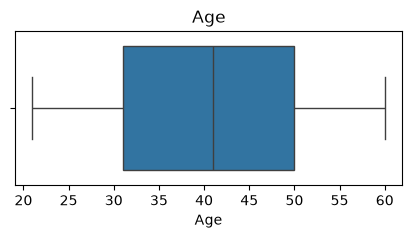

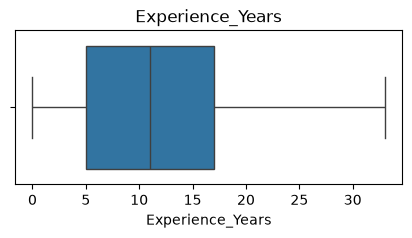

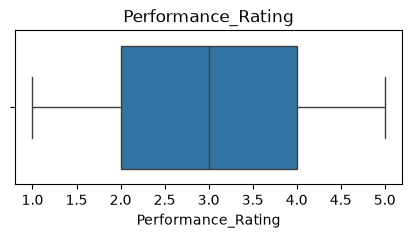

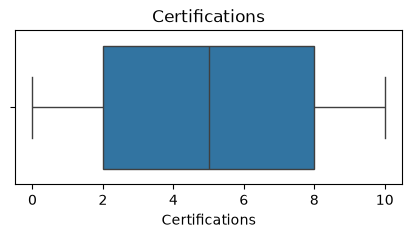

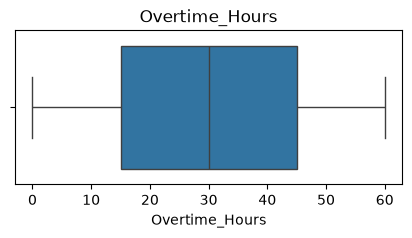

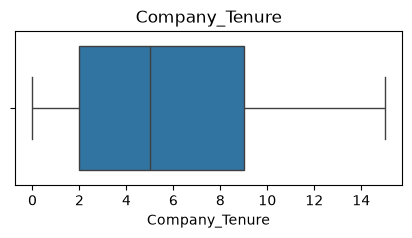

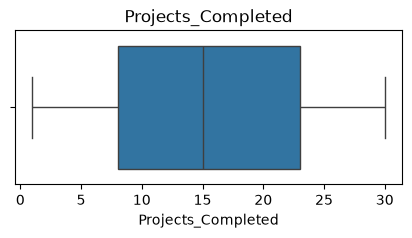

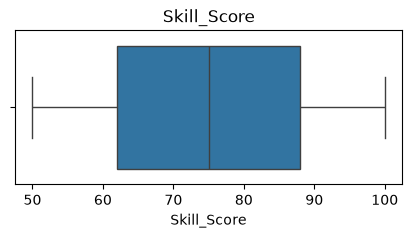

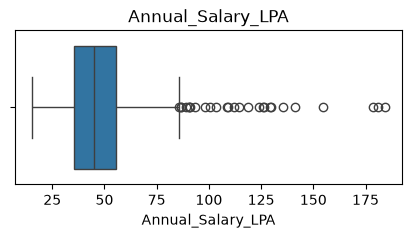

In [35]:
for col in num_cols:#A box plot helps detect unusually high or low values (outliers), which may influence the model.
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)# outlires
    plt.show()

In [36]:
 def remove_outliers(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.15*IQR
    upper=Q3+1.5*IQR
    return df[(df[column]>=lower) & (df[column]<=upper)]

In [37]:
#Removel of outliere
for col in num_cols:
    if col != "Annual_Salary_LPA":
        df=remove_outliers(df,col)

In [38]:
df.shape

(5020, 15)

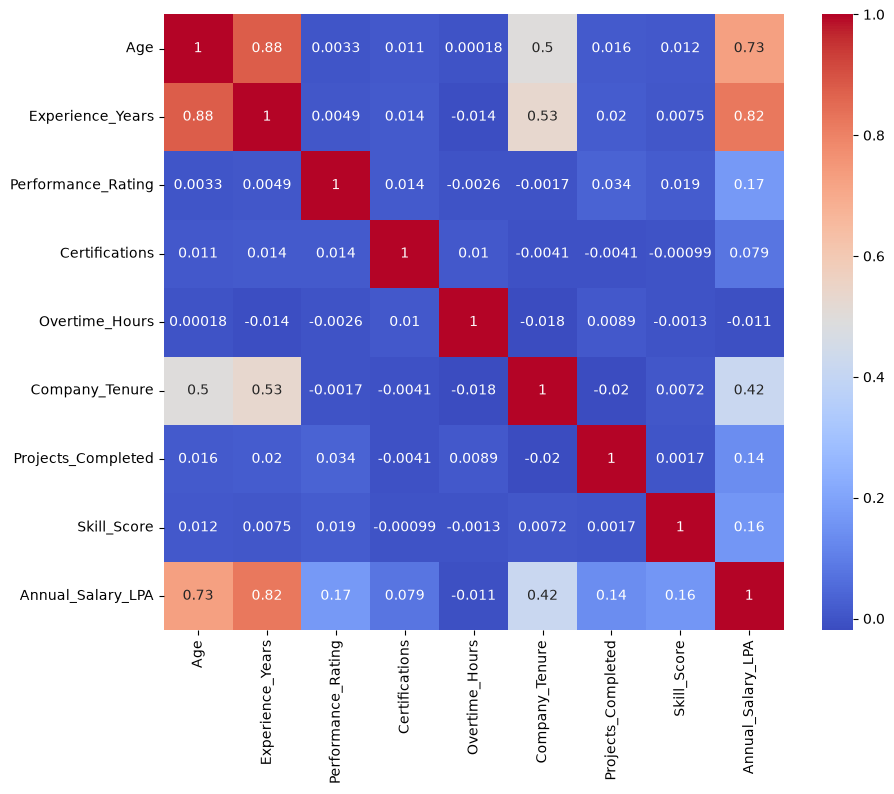

In [39]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

In [40]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [41]:
X = df.drop('Annual_Salary_LPA', axis=1)
y = df['Annual_Salary_LPA']

In [42]:
print(X.columns.tolist())

['Age', 'Gender', 'Education', 'Experience_Years', 'Department', 'Job_Level', 'Performance_Rating', 'Certifications', 'Overtime_Hours', 'Remote_Work', 'City', 'Company_Tenure', 'Projects_Completed', 'Skill_Score']


In [43]:
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

In [44]:
mm = MinMaxScaler()
X_normal = mm.fit_transform(X)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_standard,      # or X_normal
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4016, 14)
(1004, 14)
(4016,)
(1004,)


In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.4 ,-0.01, 2.16,...,-0.18, 1.77, 2.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,46.36
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](14,)","[109.65, 66.08, 65.02,..., 48.4 , 37.24, 22.04]"


In [48]:
y_pred = model.predict(X_test)

In [49]:
y_pred

array([80.45742741, 27.79707097, 43.90595113, ..., 28.25606004,
       64.09840873, 49.25648535], shape=(1004,))

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 4.101856649765889
MSE : 56.131255263154586
RMSE : 7.492079501924321
R2 Score : 0.7357299030976894


In [51]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
1504,81.44,80.457427
538,27.42,27.797071
3551,42.16,43.905951
4945,40.90,39.399724
4817,40.18,46.298292
3966,54.13,54.996649
2826,48.68,45.779954
1235,67.89,55.846011
2905,75.48,70.109687
3253,55.17,56.253430


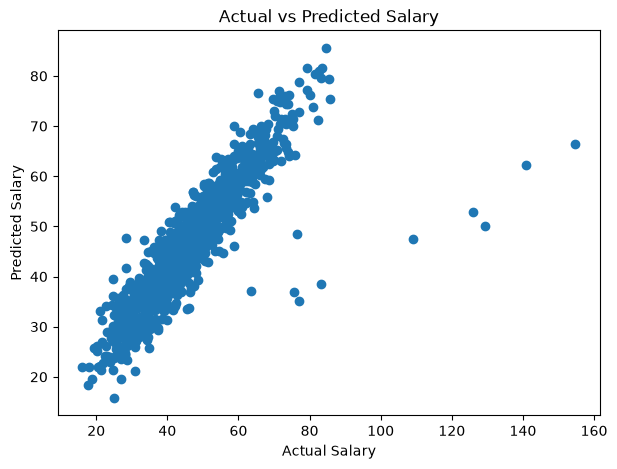

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

In [53]:
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef)

print("Intercept :", model.intercept_)

               Feature  Coefficient
0                  Age     0.398304
1               Gender    -0.007050
2            Education     2.159235
3     Experience_Years    11.978571
4           Department     0.250280
5            Job_Level    -0.598635
6   Performance_Rating     2.348969
7       Certifications     0.953407
8       Overtime_Hours    -0.043649
9          Remote_Work    -0.054206
10                City     0.814887
11      Company_Tenure    -0.183535
12  Projects_Completed     1.774139
13         Skill_Score     2.250602
Intercept : 46.3580828365695


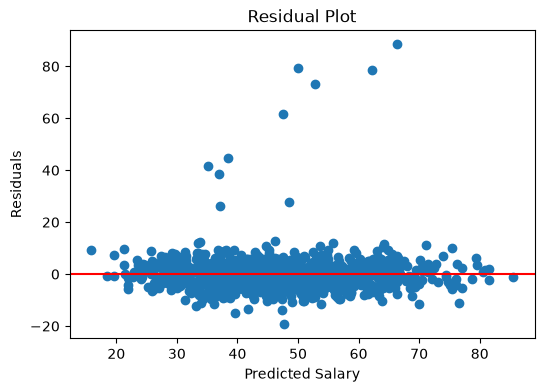

In [54]:
residuals = y_test - y_pred # NOT REQUERED ITES YOUR CHOICE YOU WANT TO VISUALISE THE DATA OR NOT

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [55]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']

In [56]:
model = joblib.load("salary_prediction_model.pkl")

In [58]:
from joblib import dump

dump(scaler, "scaler.pkl")

['scaler.pkl']

In [59]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']